In [10]:
import pandas as pd
import numpy as np
data = pd.read_excel('data/textdata.xlsx')
import  warnings
warnings.filterwarnings('ignore')

In [11]:
data.head()

,customer_id,ft1,ft2,ft3,ft4,ft5,ft6,ft7,ft8,ft9,...,gt3,gt4,gt5,gt6,gt7,gt8,gt9,gt10,gt11,gt12
0,111,9,11.0,12,13,18,10,12,NaN,NaN,...,10,0,18,10,12,NaN,NaN,NaN,NaN,NaN
1,112,11,-11.0,10,10,13,13,10,NaN,NaN,...,10,10,13,13,10,NaN,NaN,NaN,NaN,NaN
2,113,0,11.0,10,12,6,10,0,25.0,10.0,...,10,12,6,10,0,25.0,10.0,NaN,NaN,NaN
3,114,-7,-1.0,9,8,7,0,-19,10.0,11.0,...,10,10,12,0,-19,10.0,11.0,NaN,NaN,NaN
4,115,11,NaN,6,10,0,17,19,10.0,30.0,...,6,10,0,17,19,10.0,30.0,15.0,NaN,NaN


In [12]:
data.columns

Index(['customer_id', 'ft1', 'ft2', 'ft3', 'ft4', 'ft5', 'ft6', 'ft7', 'ft8',
       'ft9', 'ft10', 'ft11', 'ft12', 'TOB', 'gt1', 'gt2', 'gt3', 'gt4', 'gt5',
       'gt6', 'gt7', 'gt8', 'gt9', 'gt10', 'gt11', 'gt12'],
      dtype='str')

In [13]:
def Num(ft,p):  #ft feature name p feature > 0 months
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.where(df>0,1,0).sum(axis=1)
    return ft+'_num'+str(p),auto_value

def zero_cnt(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.where(df==0,1,0).sum(axis=1)
    return ft+'_zero_cnt'+str(p),auto_value

def Evr(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    arr=np.where(df>0,1,0).sum(axis=1)
    auto_value = np.where(arr,1,0)
    return ft+'_evr'+str(p),auto_value

def Avg(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.nanmean(df,axis = 1 )
    return ft+'_avg'+str(p),auto_value

def Tot(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.nansum(df,axis = 1)
    return ft+'_tot'+str(p),auto_value

def Tot2T(ft,p):
    df=data.loc[:,ft+'2':ft+str(p+1)]
    auto_value=df.sum(1)
    return ft+'_tot2t'+str(p),auto_value

def Max(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.nanmax(df,axis = 1)
    return ft+'_max'+str(p),auto_value

def Min(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.nanmin(df,axis = 1)
    return ft+'_min'+str(p),auto_value

def Msg(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    df_value=np.where(df>0,1,0)
    auto_value=[]
    for i in range(len(df_value)):
        row_value=df_value[i,:]
        if row_value.max()<=0:
            indexs='0'
            auto_value.append(indexs)
        else:
            indexs=1
            for j in row_value:
                if j>0:
                    break
                indexs+=1
            auto_value.append(indexs)
    return ft+'_msg'+str(p),auto_value


def Msz(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    df_value=np.where(df==0,1,0)
    auto_value=[]
    for i in range(len(df_value)):
        row_value=df_value[i,:]
        if row_value.max()<=0:
            indexs='0'
            auto_value.append(indexs)
        else:
            indexs=1
            for j in row_value:
                if j>0:
                    break
                indexs+=1
            auto_value.append(indexs)
    return ft+'_msz'+str(p),auto_value

def Cav(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = df[ft+'1']/np.nanmean(df,axis = 1 )
    return ft+'_cav'+str(p),auto_value

def Cmn(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = df[ft+'1']/np.nanmin(df,axis = 1 )
    return ft+'_cmn'+str(p),auto_value

def Mai(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        for k in range(len(df_value)-1):
            minus = df_value[k] - df_value[k+1]
            value_lst.append(minus)
        auto_value.append(np.nanmax(value_lst))
    return ft+'_mai'+str(p),auto_value

def Mad(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        for k in range(len(df_value)-1):
            minus = df_value[k+1] - df_value[k]
            value_lst.append(minus)
        auto_value.append(np.nanmax(value_lst))
    return ft+'_mad'+str(p),auto_value

def Std(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.nanvar(df,axis = 1)
    return ft+'_std'+str(p),auto_value

def Cva(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value=np.nanvar(df,axis = 1)/(np.nanmean(df,axis = 1 )+1e-10)
    return ft+'_cva'+str(p),auto_value

def Cmm(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = df[ft+'1'] - np.nanmean(df,axis = 1 )
    return ft+'_cmm'+str(p),auto_value

def Cnm(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = df[ft+'1'] - np.nanmin(df,axis = 1 )
    return ft+'_cnm'+str(p),auto_value

def Cxm(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = df[ft+'1'] - np.nanmax(df,axis = 1 )
    return ft+'_cxm'+str(p),auto_value


def Cxp(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    temp = np.nanmax(df,axis = 1 )
    auto_value = (df[ft+'1'] - temp )/ temp
    return ft+'_cxp'+str(p),auto_value

def Ran(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = np.nanmax(df,axis = 1 )  -  np.nanmin(df,axis = 1 )
    return ft+'_ran'+str(p),auto_value

def Nci(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        for k in range(len(df_value)-1):
            minus = df_value[k] - df_value[k+1]
            value_lst.append(minus)
        value_ng = np.where(np.array(value_lst)>0,1,0).sum()
        auto_value.append(np.nanmax(value_ng))
    return ft+'_nci'+str(p),auto_value

def Ncd(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        for k in range(len(df_value)-1):
            minus = df_value[k] - df_value[k+1]
            value_lst.append(minus)
        value_ng = np.where(np.array(value_lst)<0,1,0).sum()
        auto_value.append(np.nanmax(value_ng))
    return ft+'_ncd'+str(p),auto_value

def Ncn(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        for k in range(len(df_value)-1):
            minus = df_value[k] - df_value[k+1]
            value_lst.append(minus)
        value_ng = np.where(np.array(value_lst)==0,1,0).sum()
        auto_value.append(np.nanmax(value_ng))
    return ft+'_ncn'+str(p),auto_value

def Bup(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        index = 0
        for k in range(len(df_value)-1):
            if df_value[k] > df_value[k+1]:
                break
            index =+ 1
        if index == p:
            value= 1
        else:
            value = 0
        auto_value.append(value)
    return ft+'_bup'+str(p),auto_value

def Pdn(ft,p):
    arr=np.array(data.loc[:,ft+'1':ft+str(p)])
    auto_value = []
    for i in range(len(arr)):
        df_value = arr[i,:]
        value_lst = []
        index = 0
        for k in range(len(df_value)-1):
            if df_value[k+1] > df_value[k]:
                break
            index =+ 1
        if index == p:
            value= 1
        else:
            value = 0
        auto_value.append(value)
    return ft+'_pdn'+str(p),auto_value

def Trm(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = []
    for i in range(len(df)):
        trm_mean = list(df.loc[i,:])
        trm_mean.remove(np.nanmax(trm_mean))
        trm_mean.remove(np.nanmin(trm_mean))
        temp=np.nanmean(trm_mean)
        auto_value.append(temp)
    return ft+'_trm'+str(p),auto_value

def Cmx(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = (df[ft+'1'] - np.nanmax(df,axis = 1 )) /np.nanmax(df,axis = 1 )
    return ft+'_cmx'+str(p),auto_value

def Cmp(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = (df[ft+'1'] - np.nanmean(df,axis = 1 )) /np.nanmean(df,axis = 1 )
    return ft+'_cmp'+str(p),auto_value

def Cnp(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    auto_value = (df[ft+'1'] - np.nanmin(df,axis = 1 )) /np.nanmin(df,axis = 1 )
    return ft+'_cnp'+str(p),auto_value

def Msx(ft,p):
    df=data.loc[:,ft+'1':ft+str(p)]
    df['_max'] = np.nanmax(df,axis = 1)
    for i in range(1,p+1):
        df[ft+str(i)] = list(df[ft+str(i)] == df['_max'])
    del df['_max']
    df_value = np.where(df==True,1,0)
    auto_value=[]
    for i in range(len(df_value)):
        row_value=df_value[i,:]
        indexs=1
        for j in row_value:
            if j == 1:
                break
            indexs+=1
        auto_value.append(indexs)
    return ft+'_msx'+str(p),auto_value

def Rpp(ft,p):
    df1=data.loc[:,ft+'1':ft+str(p)]
    value1=np.nanmean(df1,axis = 1 )
    df2=data.loc[:,ft+str(p):ft+str(2*p)]
    value2=np.nanmean(df2,axis = 1 )
    auto_value = value1/value2
    return ft+'_rpp'+str(p),auto_value

def Dpp(ft,p):
    df1=data.loc[:,ft+'1':ft+str(p)]
    value1=np.nanmean(df1,axis = 1 )
    df2=data.loc[:,ft+str(p):ft+str(2*p)]
    value2=np.nanmean(df2,axis = 1 )
    auto_value = value1 - value2
    return ft+'_dpp'+str(p),auto_value

def Mpp(ft,p):
    df1=data.loc[:,ft+'1':ft+str(p)]
    value1=np.nanmax(df1,axis = 1 )
    df2=data.loc[:,ft+str(p):ft+str(2*p)]
    value2=np.nanmax(df2,axis = 1 )
    auto_value = value1/value2
    return ft+'_mpp'+str(p),auto_value

def Npp(ft,p):
    df1=data.loc[:,ft+'1':ft+str(p)]
    value1=np.nanmin(df1,axis = 1 )
    df2=data.loc[:,ft+str(p):ft+str(2*p)]
    value2=np.nanmin(df2,axis = 1 )
    auto_value = value1/value2
    return ft+'_npp'+str(p),auto_value

In [14]:
def auto_var2(feature,p, data_new):
    try:
        columns_name,values=Num(feature,p)
        data_new[columns_name]=values
    except:
           print("Num PARSE ERROR",feature,p)
    try:
        columns_name,values=zero_cnt(feature,p)
        data_new[columns_name]=values
    except:
           print("Nmz PARSE ERROR",feature,p)
    try:
        columns_name,values=Evr(feature,p)
        data_new[columns_name]=values
    except:
           print("Evr PARSE ERROR",feature,p)
    try:
        columns_name,values=Avg(feature,p)
        data_new[columns_name]=values
    except:
           print("Avg PARSE ERROR",feature,p)
    try:
        columns_name,values=Tot(feature,p)
        data_new[columns_name]=values
    except:
        print("Tot PARSE ERROR",feature,p)
    try:
        columns_name,values=Tot2T(feature,p)
        data_new[columns_name]=values
    except:
        print("Tot2T PARSE ERROR",feature,p)
    try:
        columns_name,values=Max(feature,p)
        data_new[columns_name]=values
    except:
        print("Tot PARSE ERROR",feature,p)
    try:
        columns_name,values=Max(feature,p)
        data_new[columns_name]=values
    except:
        print("Max PARSE ERROR",feature,p)
    try:
        columns_name,values=Min(feature,p)
        data_new[columns_name]=values
    except:
        print("Min PARSE ERROR",feature,p)
    try:
        columns_name,values=Msg(feature,p)
        data_new[columns_name]=values
    except:
        print("Msg PARSE ERROR",feature,p)
    try:
        columns_name,values=Msz(feature,p)
        data_new[columns_name]=values
    except:
        print("Msz PARSE ERROR",feature,p)
    try:
        columns_name,values=Cav(feature,p)
        data_new[columns_name]=values
    except:
        print("Cav PARSE ERROR",feature,p)
    try:
        columns_name,values=Cmn(feature,p)
        data_new[columns_name]=values
    except:
        print("Cmn PARSE ERROR",feature,p)
    try:
        columns_name,values=Std(feature,p)
        data_new[columns_name]=values
    except:
        print("Std PARSE ERROR",feature,p)
    try:
        columns_name,values=Cva(feature,p)
        data_new[columns_name]=values
    except:
        print("Cva PARSE ERROR",feature,p)
    try:
        columns_name,values=Cmm(feature,p)
        data_new[columns_name]=values
    except:
        print("Cmm PARSE ERROR",feature,p)
    try:
        columns_name,values=Cnm(feature,p)
        data_new[columns_name]=values
    except:
        print("Cnm PARSE ERROR",feature,p)
    try:
        columns_name,values=Cxm(feature,p)
        data_new[columns_name]=values
    except:
        print("Cxm PARSE ERROR",feature,p)
    try:
        columns_name,values=Cxp(feature,p)
        data_new[columns_name]=values
    except:
        print("Cxp PARSE ERROR",feature,p)
    try:
        columns_name,values=Ran(feature,p)
        data_new[columns_name]=values
    except:
        print("Ran PARSE ERROR",feature,p)
    try:
        columns_name,values=Nci(feature,p)
        data_new[columns_name]=values
    except:
        print("Nci PARSE ERROR",feature,p)
    try:
        columns_name,values=Ncd(feature,p)
        data_new[columns_name]=values
    except:
        print("Ncd PARSE ERROR",feature,p)
    try:
        columns_name,values=Ncn(feature,p)
        data_new[columns_name]=values
    except:
        print("Ncn PARSE ERROR",feature,p)
    try:
        columns_name,values=Pdn(feature,p)
        data_new[columns_name]=values
    except:
        print("Pdn PARSE ERROR",feature,p)
    try:
        columns_name,values=Cmx(feature,p)
        data_new[columns_name]=values
    except:
        print("Cmx PARSE ERROR",feature,p)
    try:
        columns_name,values=Cmp(feature,p)
        data_new[columns_name]=values
    except:
        print("Cmp PARSE ERROR",feature,p)
    try:
        columns_name,values=Cnp(feature,p)
        data_new[columns_name]=values
    except:
        print("Cnp PARSE ERROR",feature,p)
    try:
        columns_name,values=Msx(feature,p)
        data_new[columns_name]=values
    except:
        print("Msx PARSE ERROR",feature,p)
    try:
        columns_name,values=Nci(feature,p)
        data_new[columns_name]=values
    except:
        print("Nci PARSE ERROR",feature,p)
    try:
        columns_name,values=Trm(feature,p)
        data_new[columns_name]=values
    except:
        print("Trm PARSE ERROR",feature,p)
    try:
        columns_name,values=Bup(feature,p)
        data_new[columns_name]=values
    except:
        print("Bup PARSE ERROR",feature,p)
    try:
        columns_name,values=Mai(feature,p)
        data_new[columns_name]=values
    except:
        print("Mai PARSE ERROR",feature,p)
    try:
        columns_name,values=Mad(feature,p)
        data_new[columns_name]=values
    except:
        print("Mad PARSE ERROR",feature,p)
    try:
        columns_name,values=Rpp(feature,p)
        data_new[columns_name]=values
    except:
        print("Rpp PARSE ERROR",feature,p)
    try:
        columns_name,values=Dpp(feature,p)
        data_new[columns_name]=values
    except:
        print("Dpp PARSE ERROR",feature,p)
    try:
        columns_name,values=Mpp(feature,p)
        data_new[columns_name]=values
    except:
        print("Mpp PARSE ERROR",feature,p)
    try:
        columns_name,values=Npp(feature,p)
        data_new[columns_name]=values
    except:
        print("Npp PARSE ERROR",feature,p)
    return data_new.columns.size

In [15]:
data_new = pd.DataFrame()
for p in [3, 6, 12]:
    for ft_name in ['ft', 'gt']:
        auto_var2(ft_name,p,data_new)

Tot2T PARSE ERROR ft 12
Rpp PARSE ERROR ft 12
Dpp PARSE ERROR ft 12
Mpp PARSE ERROR ft 12
Npp PARSE ERROR ft 12
Tot2T PARSE ERROR gt 12
Rpp PARSE ERROR gt 12
Dpp PARSE ERROR gt 12
Mpp PARSE ERROR gt 12
Npp PARSE ERROR gt 12


In [16]:
data_new.head()

,ft_num3,ft_zero_cnt3,ft_evr3,ft_avg3,ft_tot3,ft_tot2t3,ft_max3,ft_min3,ft_msg3,ft_msz3,...,gt_ncn12,gt_pdn12,gt_cmx12,gt_cmp12,gt_cnp12,gt_msx12,gt_trm12,gt_bup12,gt_mai12,gt_mad12
0,3,0,1,10.666667,32.0,36.0,12.0,9.0,1,0,...,0,0,-0.500000,-0.100000,inf,5,10.400000,0,10.0,18.0
1,2,0,1,3.333333,10.0,9.0,11.0,-11.0,1,0,...,2,0,-0.153846,0.375000,-2.000000,5,10.800000,0,22.0,21.0
2,2,1,1,7.000000,21.0,33.0,11.0,0.0,2,1,...,0,0,-1.000000,-1.000000,NaN,8,8.428571,0,15.0,25.0
3,1,0,1,0.333333,1.0,16.0,9.0,-7.0,3,0,...,1,0,-0.153846,0.706897,-1.578947,2,9.142857,0,19.0,29.0
4,2,0,1,8.500000,17.0,16.0,11.0,6.0,1,0,...,0,0,-0.633333,-0.161017,inf,9,12.571429,0,15.0,20.0


In [17]:
data.shape

(5, 26)

In [18]:
data_new.shape

(5, 200)

In [22]:
import  toad

In [20]:
data = pd.read_csv('data/germancredit.csv')
data.head()

,status.of.existing.checking.account,duration.in.month,credit.history,purpose,credit.amount,savings.account.and.bonds,present.employment.since,installment.rate.in.percentage.of.disposable.income,personal.status.and.sex,other.debtors.or.guarantors,...,property,age.in.years,other.installment.plans,housing,number.of.existing.credits.at.this.bank,job,number.of.people.being.liable.to.provide.maintenance.for,telephone,foreign.worker,creditability
0,... < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,good
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,good
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,none,yes,good
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad


In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   status.of.existing.checking.account                       1000 non-null   str  
 1   duration.in.month                                         1000 non-null   int64
 2   credit.history                                            1000 non-null   str  
 3   purpose                                                   1000 non-null   str  
 4   credit.amount                                             1000 non-null   int64
 5   savings.account.and.bonds                                 1000 non-null   str  
 6   present.employment.since                                  1000 non-null   str  
 7   installment.rate.in.percentage.of.disposable.income       1000 non-null   int64
 8   personal.status.and.sex                           

In [23]:
data.columns

Index(['status.of.existing.checking.account', 'duration.in.month',
       'credit.history', 'purpose', 'credit.amount',
       'savings.account.and.bonds', 'present.employment.since',
       'installment.rate.in.percentage.of.disposable.income',
       'personal.status.and.sex', 'other.debtors.or.guarantors',
       'present.residence.since', 'property', 'age.in.years',
       'other.installment.plans', 'housing',
       'number.of.existing.credits.at.this.bank', 'job',
       'number.of.people.being.liable.to.provide.maintenance.for', 'telephone',
       'foreign.worker', 'creditability'],
      dtype='str')

In [24]:
data.describe()

,duration.in.month,credit.amount,installment.rate.in.percentage.of.disposable.income,present.residence.since,age.in.years,number.of.existing.credits.at.this.bank,number.of.people.being.liable.to.provide.maintenance.for
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [25]:
combiner = toad.transform.Combiner()
print(type(combiner))

<class 'toad.transform.Combiner'>


In [26]:
data['creditability'].replace({'good':0,'bad':1},inplace=True)

0      0
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: creditability, Length: 1000, dtype: object

In [27]:
combiner.fit(data,y='creditability',method='chi',min_samples=0.05)

In [28]:
data['duration.in.month'].value_counts()

duration.in.month
24    184
12    179
18    113
36     83
6      75
15     64
9      49
48     48
30     40
21     30
10     28
60     13
27     13
42     11
11      9
20      8
8       7
4       6
7       5
45      5
39      5
14      4
13      4
33      3
28      3
54      2
16      2
22      2
47      1
5       1
26      1
72      1
40      1
Name: count, dtype: int64

In [29]:
combiner.export()['duration.in.month']

[9, 12, 13, 16, 36, 45]

In [30]:
import matplotlib.pyplot as plt
from toad.plot import bin_plot
c2 = toad.transform.Combiner()
c2.fit(data[['duration.in.month','creditability']],y='creditability',method = 'chi',n_bins=7)
transformed = c2.transform(data[['duration.in.month','creditability']],labels = True)

In [31]:
transformed['duration.in.month'].value_counts()

duration.in.month
04.[16 ~ 36)     399
02.[12 ~ 13)     179
05.[36 ~ 45)     100
00.[-inf ~ 9)     94
01.[9 ~ 12)       86
03.[13 ~ 16)      72
06.[45 ~ inf)     70
Name: count, dtype: int64

<Axes: xlabel='duration.in.month', ylabel='prop'>

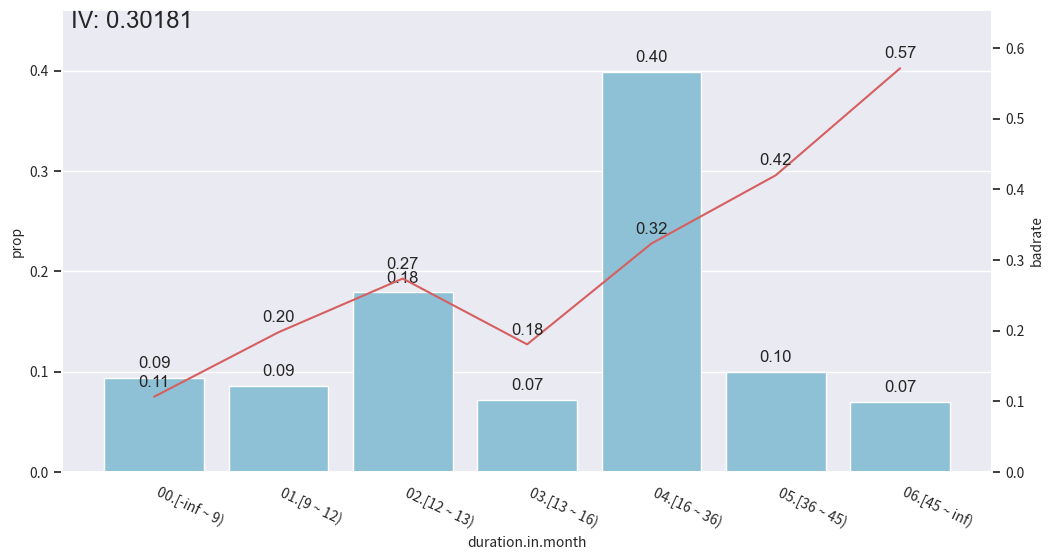

In [32]:
bin_plot(transformed,x='duration.in.month',target='creditability')

<Axes: xlabel='duration.in.month', ylabel='prop'>

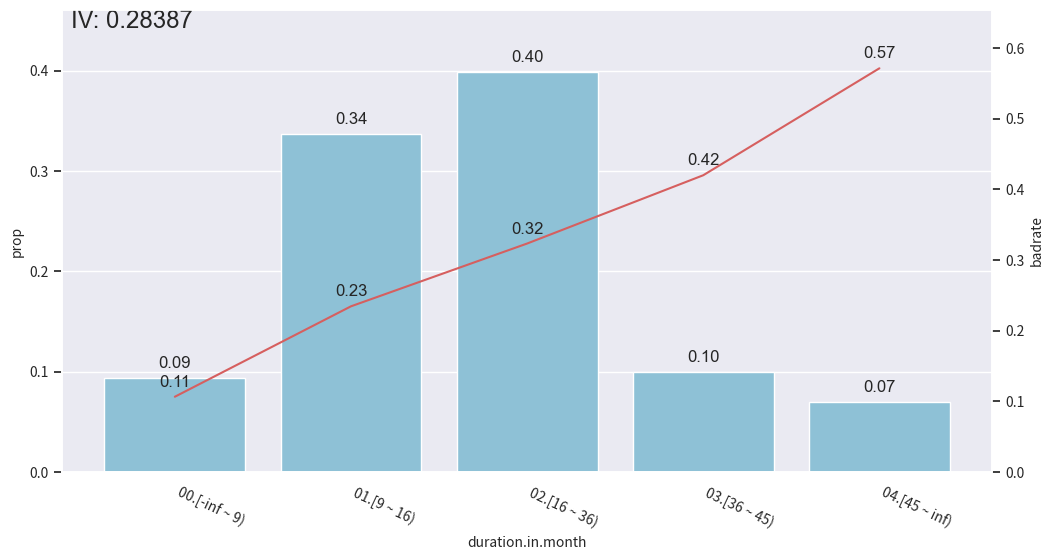

In [33]:
c2 = toad.transform.Combiner()
c2.fit(data[['duration.in.month','creditability']],y='creditability',method = 'chi',n_bins=5)
transformed = c2.transform(data[['duration.in.month','creditability']],labels = True)
bin_plot(transformed,x='duration.in.month',target='creditability')

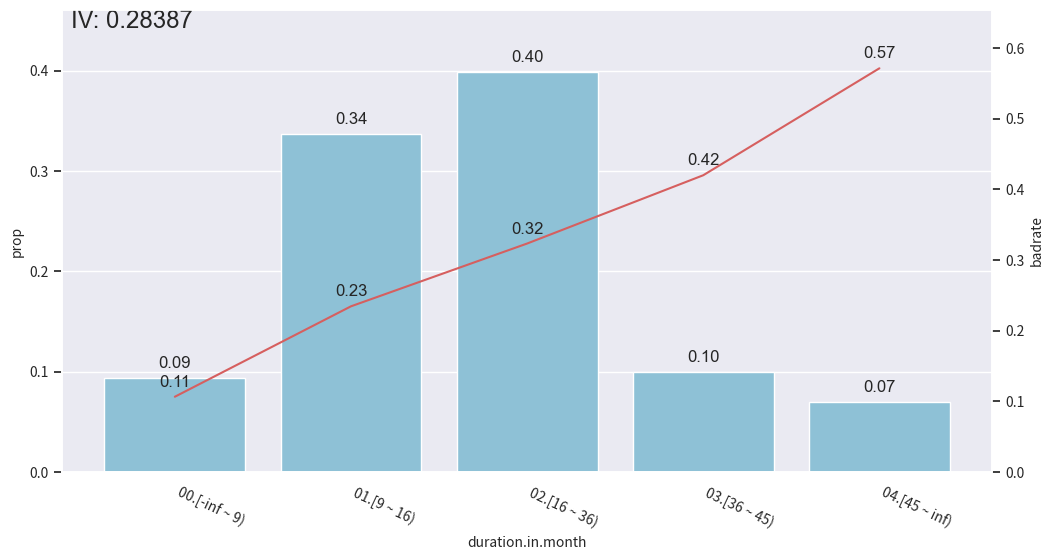

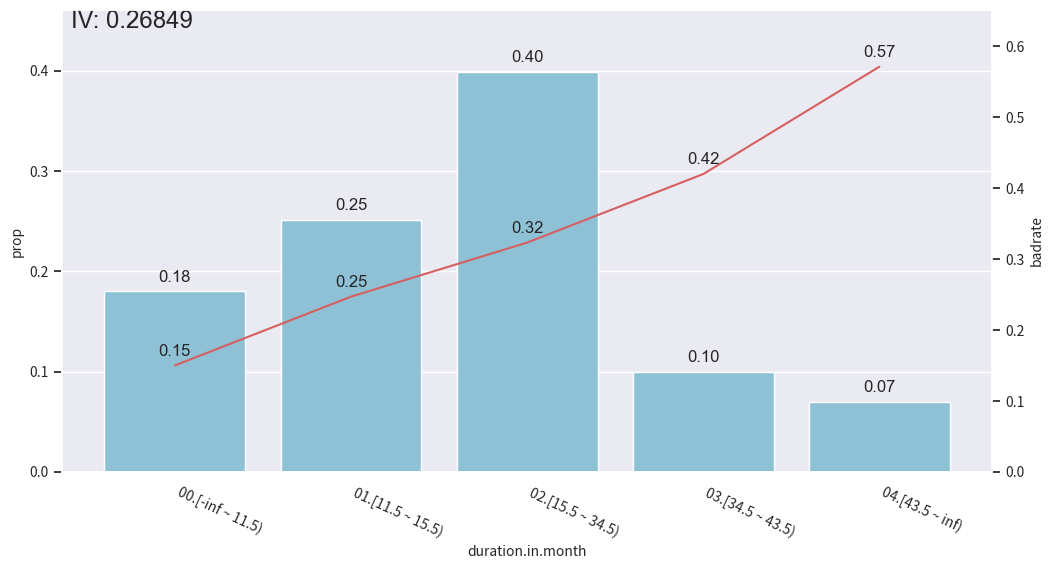

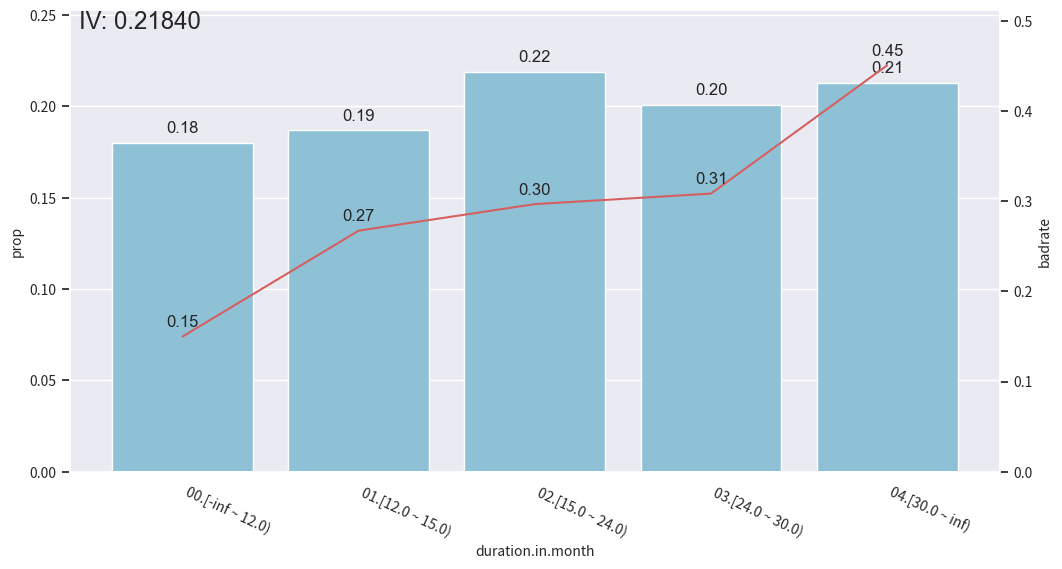

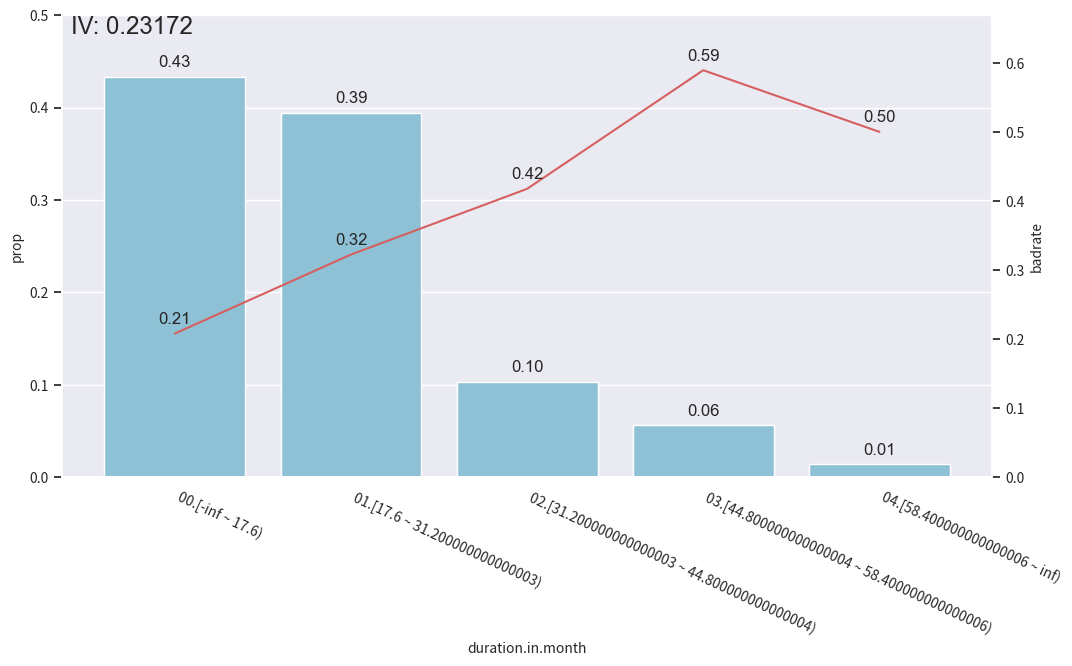

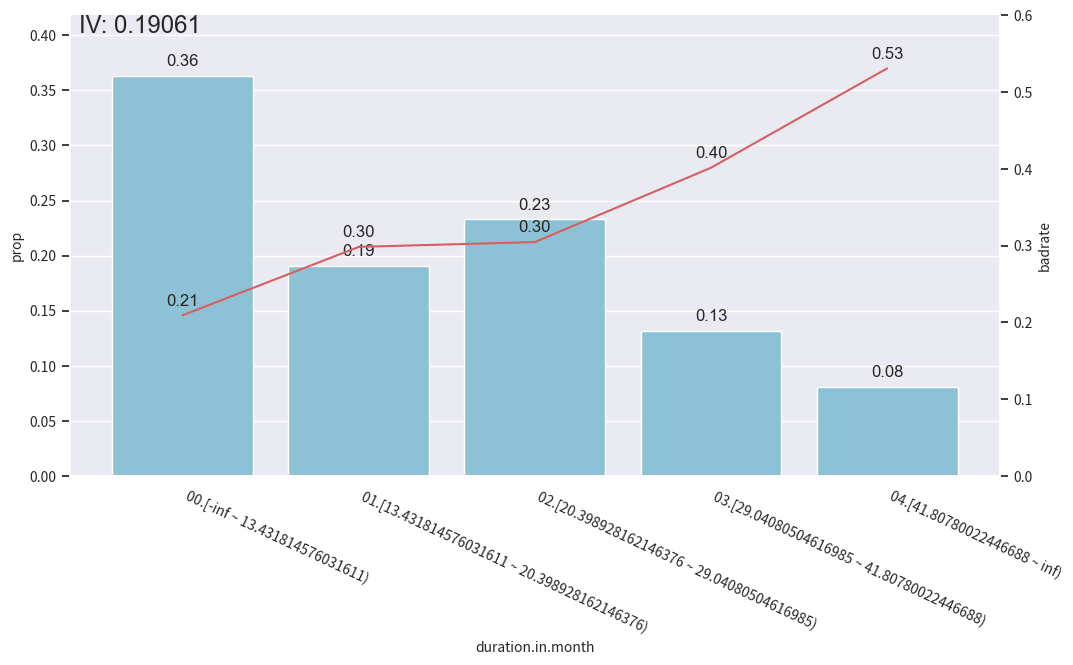

In [34]:
for method in ['chi', 'dt', 'quantile', 'step', 'kmeans']:
	c2 = toad.transform.Combiner()
	c2.fit(data[['duration.in.month','creditability']],
		y='creditability', method=method, n_bins=5)
	bin_plot(c2.transform(data[['duration.in.month','creditability']],labels=True),
		x='duration.in.month',target='creditability')

In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data.drop('creditability',axis=1),data['creditability'],test_size=0.25,random_state=450)

In [36]:
data_train = pd.concat([x_train,y_train],axis=1)
data_train['type'] = 'train'

data_test = pd.concat([x_test,y_test],axis=1)
data_test['type'] = 'test'

In [49]:
adj_bin = {'duration.in.month':[9,12,18,33]}

c1 = toad.transform.Combiner()
c1.set_rules(adj_bin)
data_ = pd.concat([data_train,data_test])

temp_data = c1.transform(data_[['duration.in.month','creditability','type']])
temp_data['creditability'] = temp_data['creditability'].map({'good': 0, 'bad': 1})
temp_data['type'] = temp_data['type'].astype('category').cat.codes



<Axes: xlabel='type', ylabel='badrate'>

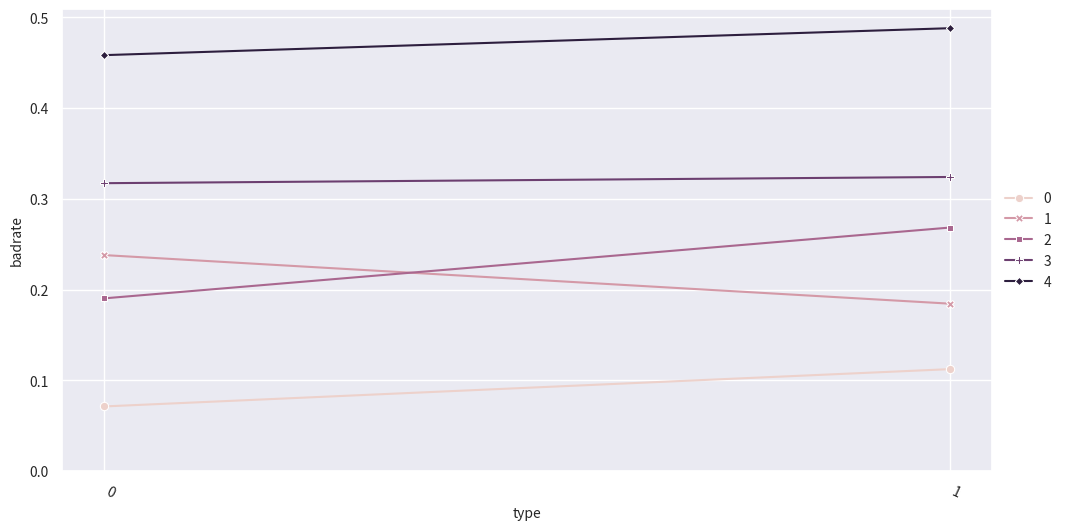

In [50]:
from toad.plot import badrate_plot,proportion_plot
badrate_plot(temp_data,target='creditability',x='type',by='duration.in.month')

In [52]:
binned_data = c1.transform(data_train)
transer = toad.transform.WOETransformer()
data_train_woe = transer.fit_transform(binned_data,binned_data['creditability'],exclude = ['creditability','type'])

In [53]:
data_train_woe['duration.in.month'].value_counts()

duration.in.month
0.0    750
Name: count, dtype: int64

In [54]:
binned_data_test = c1.transform(data_test)

In [55]:
binned_data_test

,status.of.existing.checking.account,duration.in.month,credit.history,purpose,credit.amount,savings.account.and.bonds,present.employment.since,installment.rate.in.percentage.of.disposable.income,personal.status.and.sex,other.debtors.or.guarantors,...,age.in.years,other.installment.plans,housing,number.of.existing.credits.at.this.bank,job,number.of.people.being.liable.to.provide.maintenance.for,telephone,foreign.worker,creditability,type
643,no checking account,3,critical account/ other credits existing (not ...,radio/television,1851,... < 100 DM,4 <= ... < 7 years,4,male : married/widowed,guarantor,...,33,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,good,test
17,... < 0 DM,3,no credits taken/ all credits paid back duly,business,8072,unknown/ no savings account,... < 1 year,2,male : single,none,...,25,bank,own,3,skilled employee / official,1,none,yes,good,test
150,no checking account,0,existing credits paid back duly till now,radio/television,1346,100 <= ... < 500 DM,... >= 7 years,2,male : single,none,...,42,bank,for free,1,skilled employee / official,2,"yes, registered under the customers name",yes,good,test
111,... >= 200 DM / salary assignments for at leas...,2,existing credits paid back duly till now,education,392,... < 100 DM,... < 1 year,4,female : divorced/separated/married,none,...,23,none,rent,1,skilled employee / official,1,"yes, registered under the customers name",yes,good,test
467,no checking account,4,delay in paying off in the past,radio/television,7238,unknown/ no savings account,... >= 7 years,3,male : single,none,...,32,bank,own,2,skilled employee / official,2,none,yes,good,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,no checking account,2,critical account/ other credits existing (not ...,radio/television,976,unknown/ no savings account,... >= 7 years,4,male : single,none,...,35,none,own,2,skilled employee / official,1,none,yes,good,test
601,0 <= ... < 200 DM,1,existing credits paid back duly till now,furniture/equipment,918,... < 100 DM,1 <= ... < 4 years,4,female : divorced/separated/married,none,...,30,none,own,1,skilled employee / official,1,none,yes,bad,test
666,0 <= ... < 200 DM,3,all credits at this bank paid back duly,furniture/equipment,3496,... >= 1000 DM,1 <= ... < 4 years,4,male : single,none,...,34,stores,own,1,skilled employee / official,2,"yes, registered under the customers name",yes,good,test
989,0 <= ... < 200 DM,3,critical account/ other credits existing (not ...,radio/television,1743,... < 100 DM,... >= 7 years,4,male : single,none,...,48,none,own,2,unskilled - resident,1,none,yes,good,test
